# Notebook 2: Do two different protein clusters co-localize?

<div class="custom-button-row">
    <a 
        class="custom-button custom-download-button" href="../../notebooks/09_colocalization/spatial_statistics/notebook_2.ipynb" download>
        <i class="fas fa-download"></i> Download this Notebook
    </a>
    <a
    class="custom-button custom-download-button" href="https://colab.research.google.com/github/bobiac/bobiac-book/blob/gh-pages/colab_notebooks/09_colocalization/spatial_statistics/notebook_2.ipynb" target="_blank">
        <img class="button-icon" src="../../../_static/logo/icon-google-colab.svg" alt="Open in Colab">
        Open in Colab
    </a>
</div>

In [2]:
# /// script
# requires-python = ">=3.10"
# dependencies = [
#     "matplotlib",
#     "numpy",
#     "scikit-image",
#     "scipy",
#     "tifffile",
#     "imagecodecs",
#     "pandas",
#     "seaborn",
#     "bobiac_tools @ git+https://github.com/bobiac/bobiac-tools.git"
# ]
# ///

## Overview

In this notebook, we will learn how to assess whether two proteins co-localize.

### Dataset
Our data consists of fluorescence images with five channels:
| Channel | Staining | Staining Description |
|---------|---------|----------------|
| 0 | Hoechst | Nuclear stain |
| 1 | Phalloidin | F-actin stain; whole cell marker |
| 2 | Protein A | Spot pattern |
| 3 | Protein B | Spot pattern |
| 4 | Protein C | Spot pattern |

***

## 0. Importing libraries

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import skimage
import tifffile
from bobiac_tools import overlay_labels
from scipy.spatial import KDTree

***

## 2. Load image, mask and spot table
First, we load all the data that we will need for this notebook.

In [5]:
path_image = "../../../_static/images/quant/05_spatial_stats/images/F01_202.tif"
path_mask = "../../../_static/images/quant/05_spatial_stats/masks/F01_202w1.TIF"
path_spots = "../../../_static/images/quant/05_spatial_stats/spots/F01_202_spots.csv"

image = tifffile.imread(path_image)
mask = tifffile.imread(path_mask)
df_spots = pd.read_csv(path_spots)

mask = skimage.segmentation.clear_border(mask)

### Visually inspect the images, masks and spots
To be sure that the data we are working with is corrects, we visualise it here.

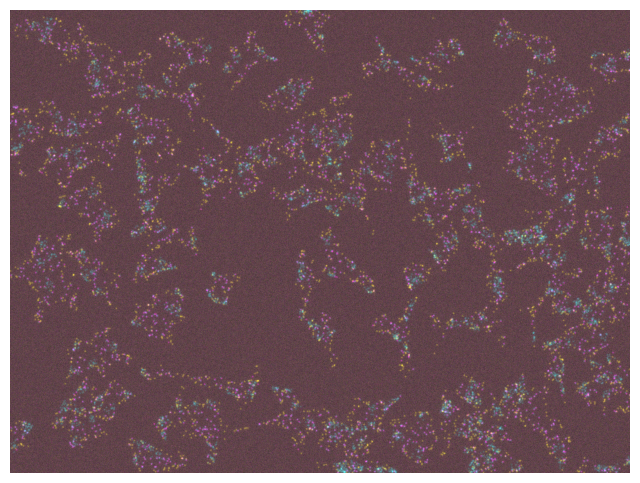

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [6]:
overlay_labels(image[2:, :, :])

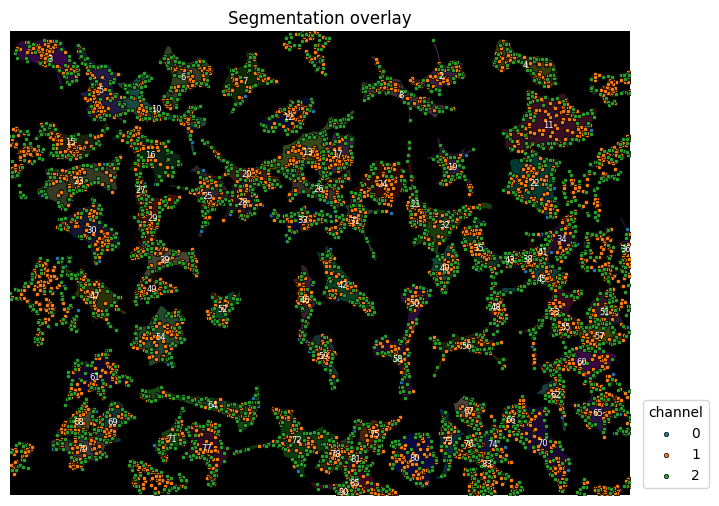

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [7]:
overlay_labels(label_mask=mask, coordinates=df_spots)

Using the `focus` attribute in `overlay` we can zoom in to view single objects.

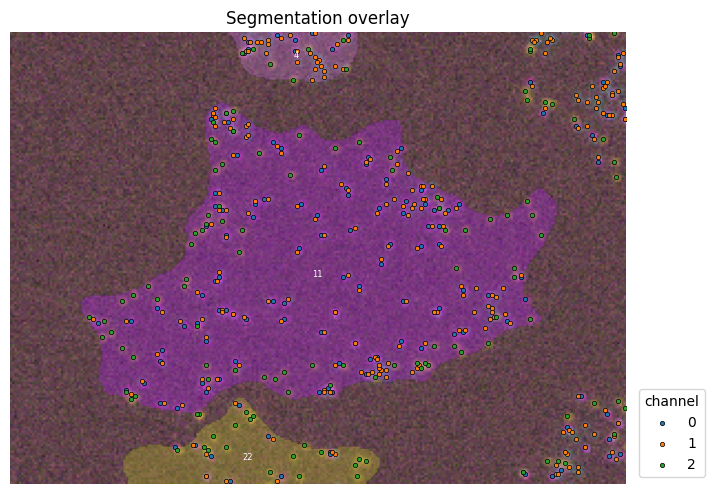

(<Figure size 800x587.05 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [9]:
overlay_labels(
    image=image[2:, :, :], label_mask=mask, coordinates=df_spots, focus_object=11
)

***

## 3. Make An Analysis Plan

### Question
**Do Protein A spots co-localize with Protein B spots?**

### Approach 
Answering this question is very similar to answering the question of if spots are clustered. Instead of finding nearest neighbours for each point within its *own* dataset, we find the nearest neighbours of points in dataset A to points in dataset B.

### Workflow

#### 1. Generate a reference for comparison
Randomly distributed set of points inside each cell's cytoplasm. We will call this the **random dataset**, which we will compare to our **protein datasets**.

#### 2. Measure the nearest neighbor distance
For every spot in dataset A, identify the closest spot in dataset B and measure the distance.

#### 3. Calculate the average nearest neighbour distance
Average the two distances across all spots in the cell.

#### 4. Calculate the Clark-Evans Index
Calculate the ratio of the average A-B distance compared to the A-random distance. 
    - **Ratio = 1:** Spots in dataset B and the spots in the random dataset are both distributed independently of spots in dataset A
    - **Ratio < 1:** Spots in dataset A co-localise with spots in dataset B
    - **Ratio > 1:** Spots in dataset A and B avoid each other  

#### 5. Calculate the p-value of the Clark-Evans Index
Calculate the p-value using a comparison of multiple random patterns.

#### 6. Calculate the reverse direction of comparison
Measure the distance of every spot in dataset B to dataset A, then repeat the analysis. The two directions are not interchangeable. If set B is much denser than A, every A point will happen to be near some B point even at random, making A→B appear co-localized by chance. Measuring B→A guards against this: if B is merely dense everywhere rather than specifically clustering around A, most B points will still be far from A and the ratio will stay near 1. True mutual co-localization produces small ratios in both directions.

***

## 4. Assemble Datasets

As before we generate a DataFrame that stores information about cells `df_cell` and another dataframe that stores information about spots `df_spots`. We then map the cell label to each spot which allows us to count how many spots exist inside each cell.

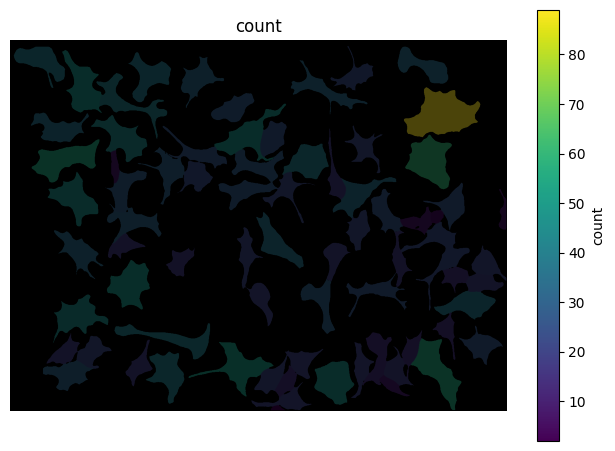

(<Figure size 800x800 with 2 Axes>, <Axes: title={'center': 'count'}>)

In [18]:
df_cell = pd.DataFrame(
    skimage.measure.regionprops_table(mask, properties=["area", "label"])
)

# map the cell label to the spots
df_spots["label_cell"] = mask[df_spots["y"].astype(int), df_spots["x"].astype(int)]
# delete spots in the background
df_spots = df_spots.loc[df_spots["label_cell"] != 0]
# count number of spots per cell label
mapping_spots = (
    df_spots.loc[df_spots["channel"] == 0]["label_cell"].value_counts().reset_index()
)
# add the cell count to the cell dataframe
df_cell = df_cell.merge(
    mapping_spots, left_on="label", right_on="label_cell", how="inner"
).drop(columns="label_cell")
overlay_labels(label_mask=mask, df=df_cell, id_col="label", measurement_col="count")

### Generate random point distribution
As before, we focus on one cell to illustrate the principles. First, we need to generate two random set of points, one each as a random distribution of the points of protein A and B (same number of points).

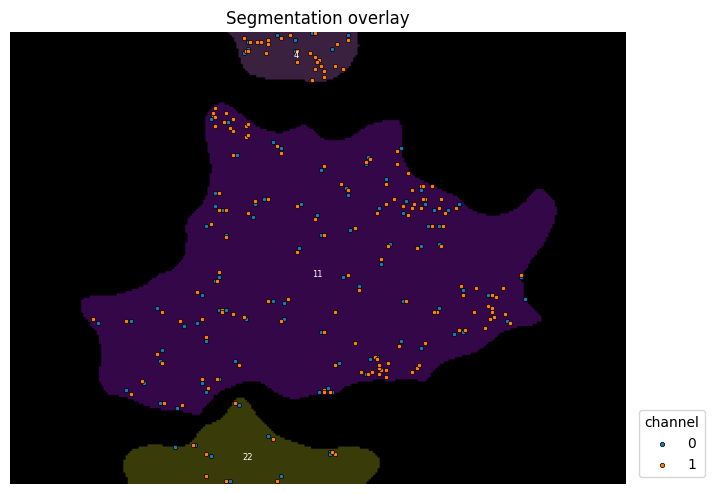

(<Figure size 800x587.05 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [19]:
cell_id = 11
overlay_labels(
    label_mask=mask,
    coordinates=df_spots.loc[df_spots["channel"].isin([0, 1])],
    focus_object=cell_id,
)

In [14]:
def random_points_in_mask(mask, cell_label, n):
    """
    Generate n random points uniformly distributed within a labeled cell region.

    Points are placed continuously using rejection sampling:
    candidate points are drawn uniformly from the bounding box of the cell and
    accepted only if they fall within the cell mask. This correctly handles
    irregular cell shapes and serves as a null model for Complete Spatial
    Randomness (CSR).

    Parameters
    ----------
    mask : 2D numpy array
        Label mask where each cell is identified by a unique integer ID
        and background is 0.
    cell_label : int
        ID of the cell to sample within.
    n : int
        Number of random points to generate.

    Returns
    -------
    points : (n, 2) numpy array
        Random point coordinates in (row, col) / (y, x) order.
    """
    ys, xs = np.where(mask == cell_label)
    y_min, y_max = ys.min(), ys.max()
    x_min, x_max = xs.min(), xs.max()
    points = []
    while len(points) < n:
        y = np.random.uniform(y_min, y_max)
        x = np.random.uniform(x_min, x_max)
        if mask[int(round(y)), int(round(x))] == cell_label:
            points.append([y, x])
    return np.array(points)

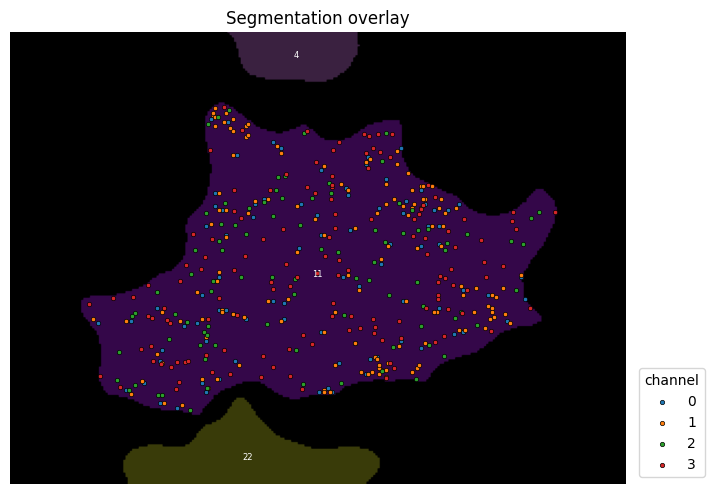

(<Figure size 800x587.05 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [20]:
spots_A = df_spots.loc[
    (df_spots["channel"] == 0) & (df_spots["label_cell"] == cell_id)
][["y", "x"]].to_numpy()
spots_B = df_spots.loc[
    (df_spots["channel"] == 1) & (df_spots["label_cell"] == cell_id)
][["y", "x"]].to_numpy()

n_A, n_B = spots_A.shape[0], spots_B.shape[0]

rnd_A = random_points_in_mask(mask, cell_label=cell_id, n=n_A)
rnd_B = random_points_in_mask(mask, cell_label=cell_id, n=n_B)

overlay_labels(
    label_mask=mask, coordinates=[spots_A, spots_B, rnd_A, rnd_B], focus_object=cell_id
)

Note that channel 2, 3 in this overlay are the newly generated random distributions.

***

## 5. Calculate Nearest Neighbour Distances
We calculate the nearest neighbour distances from 
* protein A spots to protein B spots
* protein B spots to protein A spots
* protein A spots to randomised B spots
* protein B spots to randomised A spots

In [21]:
nn_AtoB = KDTree(spots_B).query(spots_A, k=1)[0].mean()
nn_BtoA = KDTree(spots_A).query(spots_B, k=1)[0].mean()

nn_ArndB = KDTree(rnd_B).query(spots_A, k=1)[0].mean()
nn_BrndA = KDTree(rnd_A).query(spots_B, k=1)[0].mean()

print("Mean NN dist. A->B:", nn_AtoB)
print("Mean NN dist. B->A:", nn_BtoA)
print("Mean NN dist. A->random(B):", nn_ArndB)
print("Mean NN dist. B->random(A):", nn_BrndA)

Mean NN dist. A->B: 1.9655708446943665
Mean NN dist. B->A: 3.207888882211614
Mean NN dist. A->random(B): 6.953067250962778
Mean NN dist. B->random(A): 6.853840980507347


***

## 6. Calculate Clark-Evans Indices

Now we can calculate our Clark-Evans indices.

In [22]:
ce_AB = nn_AtoB / nn_ArndB
ce_BA = nn_BtoA / nn_BrndA

print("Clark-Evans index A->B:", ce_AB)
print("Clark-Evans index B->A:", ce_BA)

Clark-Evans index A->B: 0.2826911884711309
Clark-Evans index B->A: 0.4680425022020505


***

## 7. Repeat Steps 4-6 with Multiple Random Patterns
As before, we need to compare to multiple random patterns.  

In [23]:
n_repeats = 100

sims_AtoB, sims_BtoA = [], []
for _ in range(n_repeats):
    rnd_A = random_points_in_mask(mask, cell_label=cell_id, n=n_A)
    rnd_B = random_points_in_mask(mask, cell_label=cell_id, n=n_B)
    sims_AtoB.append(KDTree(rnd_B).query(spots_A, k=1)[0].mean())
    sims_BtoA.append(KDTree(rnd_A).query(spots_B, k=1)[0].mean())

sims_AtoB = np.array(sims_AtoB)
sims_BtoA = np.array(sims_BtoA)

print("nn_AtoB", nn_AtoB)
print("nn_BtoA", nn_BtoA)
print("nn_random_AtoB", sims_AtoB.mean())
print("nn_random_BtoA", sims_BtoA.mean())
print("ce_AtoB", nn_AtoB / sims_AtoB.mean())
print("ce_BtoA", nn_BtoA / sims_BtoA.mean())
print("pval_AtoB", (sims_AtoB <= nn_AtoB).mean())
print("pval_BtoA", (sims_BtoA <= nn_BtoA).mean())

nn_AtoB 1.9655708446943665
nn_BtoA 3.207888882211614
nn_random_AtoB 5.985839662095817
nn_random_BtoA 7.643994495959732
ce_AtoB 0.32837011274140326
ce_BtoA 0.41966132810628765
pval_AtoB 0.0
pval_BtoA 0.0


***

## 8. Per-cell Colocalization Measurements

### ✍️ Exercise: Summarise the per-cell co-localisation analysis as a function

To make processing individual cells simpler, we can summarise our above analysis in a function called `CrossNN`.
The function should have the following features:

**Parameters**
spots_A, spots_B : (n, 2) numpy arrays
    Spot coordinates in (row, col) / (y, x) order.
mask : 2D numpy array
    Label mask where each cell is identified by a unique integer ID.
cell_id : int
    ID of the cell in mask that both spot sets belong to.
n_repeats : int
    Number of CSR simulations to run.

**Returns**
dict with keys:
    nn_AtoB, nn_BtoA : float
        Observed mean cross-NN distance in each direction.
    nn_random_AtoB, nn_random_BtoA : float
        Mean of simulated cross-NN distances under CSR.
    ce_AtoB, ce_BtoA : float
        Cross Clark-Evans index (observed / random). < 1 indicates
        co-localization, > 1 indicates avoidance.
    pval_AtoB, pval_BtoA : float
        Fraction of simulations with cross-NN <= observed.
        Small values indicate significant co-localization.


In [24]:
def CrossNN(spots_A, spots_B, mask, cell_id, n_repeats):
    """
    Test whether two sets of spots are more co-localized than expected under
    CSR using cross nearest-neighbor distances.

    For each point in A, the nearest neighbor in B is found (and vice versa).
    The observed mean cross-NN distances are compared to a null distribution
    where both sets are independently randomized within the cell mask.

    The two directions (A→B and B→A) can differ when the sets have different
    sizes: a small set is always close to a large one even by chance.

    Parameters
    ----------
    spots_A, spots_B : (n, 2) numpy arrays
        Spot coordinates in (row, col) / (y, x) order.
    mask : 2D numpy array
        Label mask where each cell is identified by a unique integer ID.
    cell_id : int
        ID of the cell in mask that both spot sets belong to.
    n_repeats : int
        Number of CSR simulations to run.

    Returns
    -------
    dict with keys:
        nn_AtoB, nn_BtoA : float
            Observed mean cross-NN distance in each direction.
        nn_random_AtoB, nn_random_BtoA : float
            Mean of simulated cross-NN distances under CSR.
        ce_AtoB, ce_BtoA : float
            Cross Clark-Evans index (observed / random). < 1 indicates
            co-localization, > 1 indicates avoidance.
        pval_AtoB, pval_BtoA : float
            Fraction of simulations with cross-NN <= observed.
            Small values indicate significant co-localization.
    """
    n_A, n_B = spots_A.shape[0], spots_B.shape[0]

    # observed cross-NN distances
    nn_AtoB = KDTree(spots_B).query(spots_A, k=1)[0].mean()
    nn_BtoA = KDTree(spots_A).query(spots_B, k=1)[0].mean()

    sims_AtoB, sims_BtoA = [], []
    for _ in range(n_repeats):
        rnd_A = random_points_in_mask(mask, cell_label=cell_id, n=n_A)
        rnd_B = random_points_in_mask(mask, cell_label=cell_id, n=n_B)
        sims_AtoB.append(KDTree(rnd_B).query(spots_A, k=1)[0].mean())
        sims_BtoA.append(KDTree(rnd_A).query(spots_B, k=1)[0].mean())

    sims_AtoB = np.array(sims_AtoB)
    sims_BtoA = np.array(sims_BtoA)

    return {
        "nn_AtoB": nn_AtoB,
        "nn_BtoA": nn_BtoA,
        "nn_random_AtoB": sims_AtoB.mean(),
        "nn_random_BtoA": sims_BtoA.mean(),
        "ce_AtoB": nn_AtoB / sims_AtoB.mean(),
        "ce_BtoA": nn_BtoA / sims_BtoA.mean(),
        "pval_AtoB": (sims_AtoB <= nn_AtoB).mean(),
        "pval_BtoA": (sims_BtoA <= nn_BtoA).mean(),
    }

In [25]:
spots_A = df_spots.loc[
    (df_spots["channel"] == 0) & (df_spots["label_cell"] == cell_id)
][["y", "x"]].to_numpy()
spots_B = df_spots.loc[
    (df_spots["channel"] == 1) & (df_spots["label_cell"] == cell_id)
][["y", "x"]].to_numpy()
CrossNN(spots_A=spots_A, spots_B=spots_B, mask=mask, cell_id=cell_id, n_repeats=10)

{'nn_AtoB': 1.9655708446943665,
 'nn_BtoA': 3.207888882211614,
 'nn_random_AtoB': 6.020309503461387,
 'nn_random_BtoA': 7.209134248392713,
 'ce_AtoB': 0.3264899991544053,
 'ce_BtoA': 0.4449756061800094,
 'pval_AtoB': 0.0,
 'pval_BtoA': 0.0}

### Repeat measurements for all cells
So far, we have focussed on one single cell. Of course, we need to analyse all cells. 

In [26]:
n_repeats = 10

results = []
for cell_id in df_cell["label"].unique():
    spots_A = df_spots.loc[
        (df_spots["channel"] == 0) & (df_spots["label_cell"] == cell_id)
    ][["y", "x"]].to_numpy()
    spots_B = df_spots.loc[
        (df_spots["channel"] == 1) & (df_spots["label_cell"] == cell_id)
    ][["y", "x"]].to_numpy()

    # calculate the NN distance, Clark-Evans index and p-value for that cell
    results.append(
        CrossNN(
            spots_A=spots_A,
            spots_B=spots_B,
            mask=mask,
            cell_id=cell_id,
            n_repeats=n_repeats,
        )
    )

df_cell = pd.concat([df_cell, pd.DataFrame(results)], axis=1)
df_cell

,area,label,count,nn_AtoB,nn_BtoA,nn_random_AtoB,nn_random_BtoA,ce_AtoB,ce_BtoA,pval_AtoB,pval_BtoA
0,4669.0,2,23,1.742602,5.578599,4.438285,8.724695,0.392630,0.639403,0.0,0.0
1,7866.0,3,39,1.776632,3.954749,5.032229,7.221966,0.353051,0.547600,0.0,0.0
2,6945.0,4,34,1.764162,5.842747,4.791266,7.322254,0.368204,0.797944,0.0,0.0
3,9735.0,5,48,1.777044,4.682295,5.373606,6.885282,0.330699,0.680044,0.0,0.0
4,7749.0,6,38,1.730490,6.242496,4.974762,7.817387,0.347854,0.798540,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
72,9504.0,80,47,1.715710,3.593778,5.218910,7.645503,0.328749,0.470051,0.0,0.0
73,2878.0,81,14,1.504764,7.685147,3.670698,8.066098,0.409939,0.952771,0.0,0.4
74,1881.0,83,9,2.093022,10.883218,2.967278,8.409716,0.705367,1.294124,0.1,0.9
75,4198.0,85,20,1.648309,6.056318,4.338207,8.053261,0.379952,0.752033,0.0,0.1


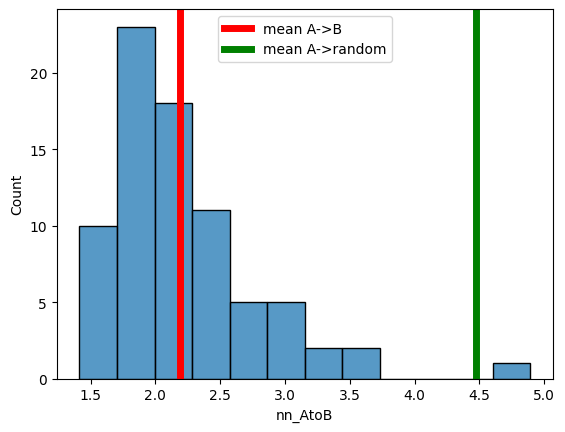

In [27]:
sns.histplot(
    df_cell,
    x="nn_AtoB",
)
plt.axvline(df_cell["nn_AtoB"].mean(), c="red", lw=5, label="mean A->B")
plt.axvline(df_cell["nn_random_AtoB"].mean(), c="green", lw=5, label="mean A->random")
plt.legend()

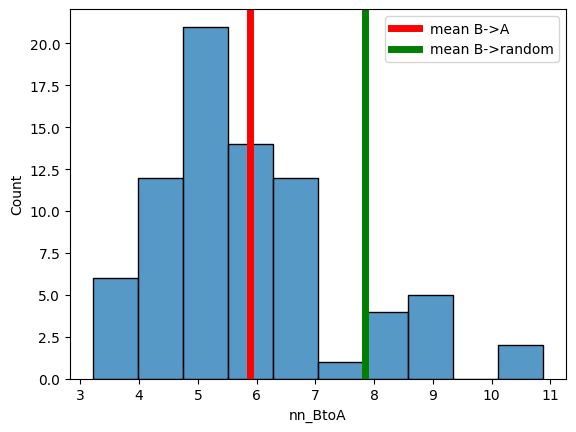

In [28]:
sns.histplot(
    df_cell,
    x="nn_BtoA",
)
plt.axvline(df_cell["nn_BtoA"].mean(), c="red", lw=5, label="mean B->A")
plt.axvline(df_cell["nn_random_BtoA"].mean(), c="green", lw=5, label="mean B->random")
plt.legend()

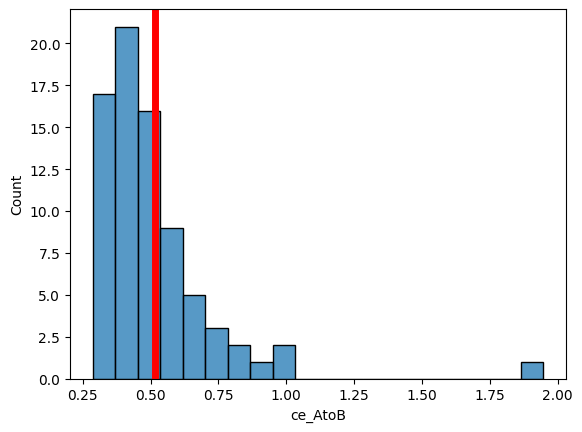

In [29]:
sns.histplot(
    df_cell,
    x="ce_AtoB",
)
plt.axvline(df_cell["ce_AtoB"].mean(), c="red", lw=5)

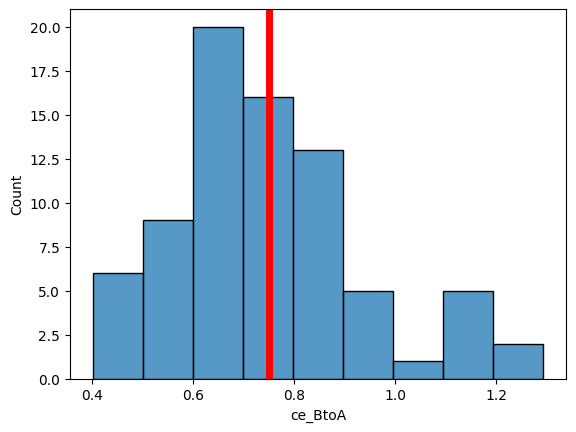

In [30]:
sns.histplot(
    df_cell,
    x="ce_BtoA",
)
plt.axvline(df_cell["ce_BtoA"].mean(), c="red", lw=5)

**Interpretation:** Almost all of protein A associates with protein B but not vice versa. 

## Conclusion
Here we have learned how to assess if two point patterns co-localise more than expected by random chance. Note that:
* The distance metric (distance to nearest neighbor) was a choice and could have been replaced with e.g. distance to the k nearest neighbors, number of spots in a certain radius or others.
* Using a complete spatially random pattern as null distribution was a choice. We could have e.g. randomised the labels between A and B.
* The formalism used to define spatial relationships (KDTree) was a choice. Other options exist.

All these choices need to be made with your scientific question in mind.

Moreover, other techniques for assessing co-localisation exist such as:
* Spatial cross-correlation: Takes into account expression levels
* Ripleys L for cross correlation: Reports on clustering length scales